# EDA - Base de Datos Teams (Hotel Cali)

Exploración de los archivos en la carpeta **BASE DE DATOS TEAMS**:
- **resenas_hotel_2500_pos_neg_completa.csv**: reseñas con comentarios positivos/negativos y rating
- **base_datos_hotel_cali_.csv**: datos operativos de reservas (tarifas, fechas, canales, etc.)

In [2]:
# Configuración y librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo y tamaño de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Ruta de la carpeta con los datos
CARPETA_DATOS = Path(r"../data")
archivos = list(CARPETA_DATOS.glob("*.csv"))
print("Archivos CSV encontrados:", [f.name for f in archivos])

Archivos CSV encontrados: ['Balanced_AHR.csv', 'Big_AHR.csv', 'dataset_hoteles_es_final_UTF8BOM.csv', 'resenas_hotel.csv']


## 1. Carga de datos

Los CSV usan **punto y coma (;)** como separador.

In [6]:
# Carga con separador ;
df_resenas = pd.read_csv(CARPETA_DATOS / "resenas_hotel.csv", sep=",", encoding="utf-8")
print("=== RESEÑAS ===")
print(f"Dimensiones: {df_resenas.shape[0]} filas, {df_resenas.shape[1]} columnas")


=== RESEÑAS ===
Dimensiones: 5500 filas, 8 columnas


## 2. EDA - Reseñas (resenas_hotel_2500_pos_neg_completa.csv)

In [7]:
# Info y tipos
df_resenas.info()
df_resenas.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Reserva           5500 non-null   int64 
 1   Sexo                 5500 non-null   object
 2   Tipo_Habitacion      5500 non-null   object
 3   Motivo_Viaje         5500 non-null   object
 4   Comentario_Positivo  4141 non-null   object
 5   Comentario_Negativo  3806 non-null   object
 6   Reseña_Completa      5500 non-null   object
 7   Rating               5500 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 343.9+ KB


,ID_Reserva,Sexo,Tipo_Habitacion,Motivo_Viaje,Comentario_Positivo,Comentario_Negativo,Reseña_Completa,Rating
0,84810,M,Doble (1 cama),DEPORTIVO,la habitacion eStaba limpia,NaN,La habitacion rstaba limpiia.,4
1,15592,M,Doble (1 cama),DEPORTIVO,el personal fue muy amable,falta mantenimiento en algunas areas,El personal fue muy amable. sin embargo falta ...,4
2,4278,F,Doble Twin (2 camas),TURISMO,la piscina estaba muy bien,habiA olor raro enla habitacion,"La piscina estaba muy bien, la verdad habiA ol...",3
3,98196,F,Cuádruple,OTRO,las camas eran comodas,se escuchaba todo del pasillo,Las camas eran comodas. eso sí se escuchaba to...,3
4,37048,M,Triple,SALUD,todo estuvo bien en generral,NaN,Todo estuvo bien en generral. Volvería.,4
5,33098,F,Sencilla,NEGOCIO,NaN,NaN,estuvo ok,2
6,30256,M,Sencilla,NEGOCIO,el wifi funcionaba bien,habia humedad en el cuarto,El wifi funcionaba bien. igual habia humedad e...,2
7,19289,M,Doble (1 cama),DEPORTIVO,la habitación estaba limpia,NaN,La habitación estaba limpia. Lo recomiendo.,4
8,97530,M,Doble Twin (2 camas),NEGOCIO,buena relacion calidad preCio,los muebles estaban algo deteriorados,Buena relacion calidad precio. Los muebles est...,3
9,14434,F,Sencilla,OTRO,todo estuvo bien en general,la comida llego fria,"Todo estuvo bien en general, la verdad la comi...",4


In [8]:
# Estadísticas descriptivas (numéricas) y valores únicos en categóricas
print("Describe (numérico):")
display(df_resenas.describe(include=[np.number]))
print("\nValores únicos por columna:")
for col in df_resenas.columns:
    print(f"  {col}: {df_resenas[col].nunique()} únicos")

Describe (numérico):


,ID_Reserva,Rating
count,5500.000000,5500.000000
mean,51179.593455,3.418364
std,28519.931634,0.981401
min,1022.000000,1.000000
25%,26439.750000,3.000000
50%,51199.500000,3.000000
75%,76018.500000,4.000000
max,99994.000000,5.000000



Valores únicos por columna:
  ID_Reserva: 5500 únicos
  Sexo: 2 únicos
  Tipo_Habitacion: 6 únicos
  Motivo_Viaje: 6 únicos
  Comentario_Positivo: 709 únicos
  Comentario_Negativo: 821 únicos
  Reseña_Completa: 3931 únicos
  Rating: 5 únicos


In [10]:
# Contar registros con comentario positivo
n_positivo = df_resenas['Comentario_Positivo'].notna().sum()
# Contar registros con comentario negativo
n_negativo = df_resenas['Comentario_Negativo'].notna().sum()
# Contar registros que NO tienen ni comentario positivo NI negativo PERO sí tienen reseña completa
n_solo_resena = df_resenas[
    df_resenas['Comentario_Positivo'].isna() &
    df_resenas['Comentario_Negativo'].isna() &
    df_resenas['Reseña_Completa'].notna()
].shape[0]

print(f"Registros con Comentario_Positivo: {n_positivo}")
print(f"Registros con Comentario_Negativo: {n_negativo}")
print(f"Registros SIN positivo/negativo pero CON Reseña_Completa: {n_solo_resena}")

Registros con Comentario_Positivo: 4141
Registros con Comentario_Negativo: 3806
Registros SIN positivo/negativo pero CON Reseña_Completa: 362


In [11]:
# Longitud de texto en comentarios (para análisis NLP)
text_cols = ["Comentario_Positivo", "Comentario_Negativo", "Reseña_Completa"]
for col in text_cols:
    if col in df_resenas.columns:
        lengths = df_resenas[col].fillna("").str.len()
        print(f"{col}: media={lengths.mean():.0f}, mediana={lengths.median():.0f}, min={lengths.min()}, max={lengths.max()}")

Comentario_Positivo: media=21, mediana=25, min=0, max=44
Comentario_Negativo: media=24, mediana=26, min=0, max=101
Reseña_Completa: media=56, mediana=57, min=9, max=150


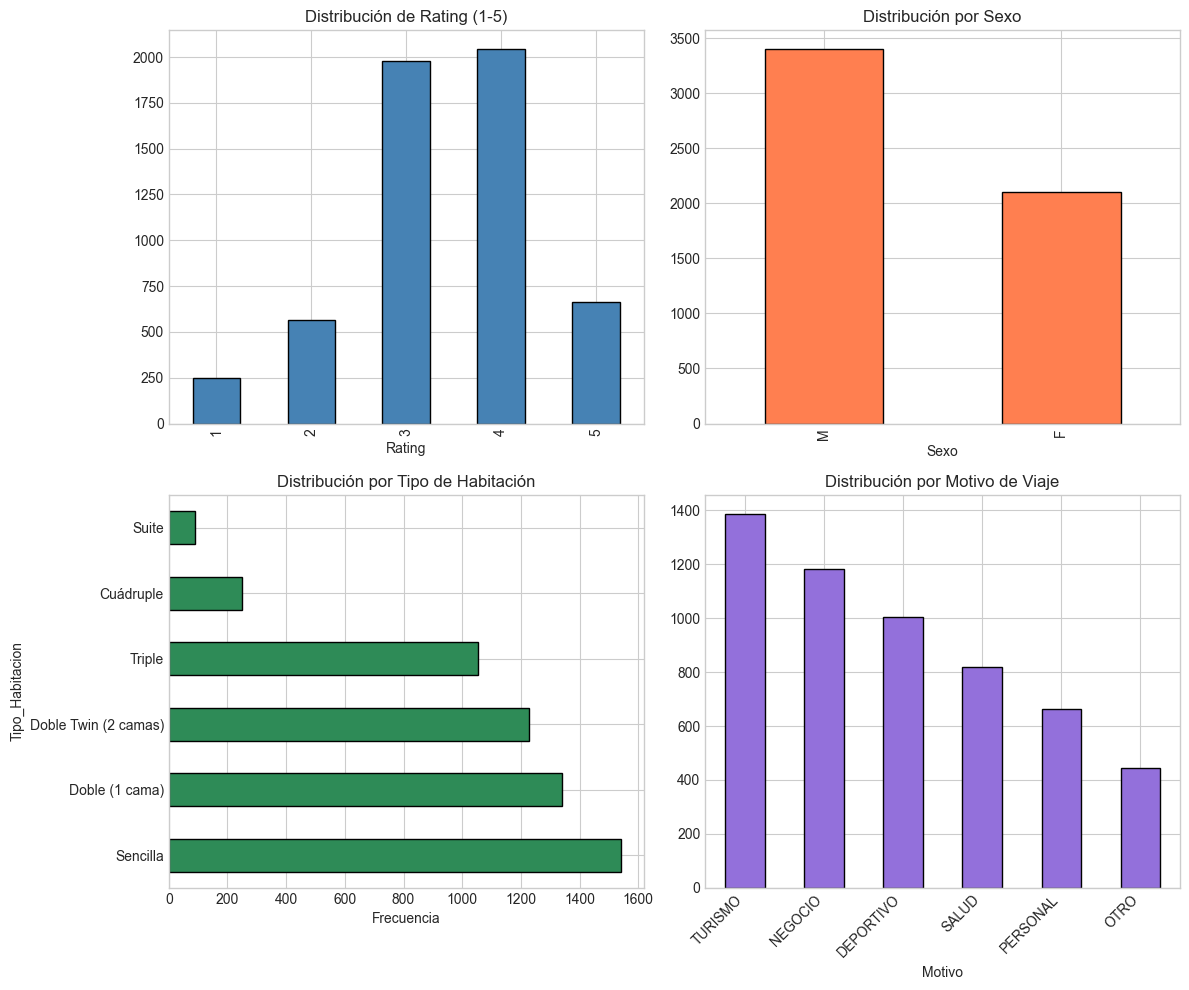

In [12]:
# Visualizaciones - Reseñas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Rating
df_resenas["Rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0,0], color="steelblue", edgecolor="black")
axes[0,0].set_title("Distribución de Rating (1-5)")
axes[0,0].set_xlabel("Rating")

# Sexo
df_resenas["Sexo"].value_counts().plot(kind="bar", ax=axes[0,1], color="coral", edgecolor="black")
axes[0,1].set_title("Distribución por Sexo")
axes[0,1].set_xlabel("Sexo")

# Tipo habitación
df_resenas["Tipo_Habitacion"].value_counts().plot(kind="barh", ax=axes[1,0], color="seagreen", edgecolor="black")
axes[1,0].set_title("Distribución por Tipo de Habitación")
axes[1,0].set_xlabel("Frecuencia")

# Motivo viaje
df_resenas["Motivo_Viaje"].value_counts().plot(kind="bar", ax=axes[1,1], color="mediumpurple", edgecolor="black")
axes[1,1].set_title("Distribución por Motivo de Viaje")
axes[1,1].set_xlabel("Motivo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

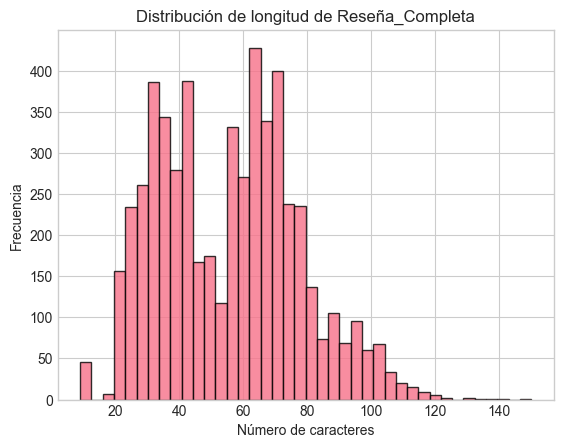

In [13]:
# Longitud de reseña completa (histograma)
df_resenas["len_resena"] = df_resenas["Reseña_Completa"].fillna("").str.len()
df_resenas["len_resena"].hist(bins=40, edgecolor="black", alpha=0.8)
plt.title("Distribución de longitud de Reseña_Completa")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

In [15]:
num_resenas_completas = df_resenas["Reseña_Completa"].notna().sum()
print(f"Número de registros con reseña completa: {num_resenas_completas}")

Número de registros con reseña completa: 5500


In [16]:
# Verificamos si comentarios (comentario_positivo o comentario_negativo) junto con reseña completa existen
filtro = (
    df_resenas["Reseña_Completa"].notna() &
    (
        df_resenas["Comentario_Positivo"].notna() | 
        df_resenas["Comentario_Negativo"].notna()
    )
)

resenas_con_comentarios = df_resenas[filtro]
print(f"Número de reseñas completas con comentario positivo o negativo: {len(resenas_con_comentarios)}")

Número de reseñas completas con comentario positivo o negativo: 5138


In [18]:
# Filtramos registros que NO tienen comentario positivo NI negativo, pero SI tienen reseña completa
filtro_solo_resena = (
    df_resenas["Reseña_Completa"].notna() &
    df_resenas["Comentario_Positivo"].isna() &
    df_resenas["Comentario_Negativo"].isna()
)

solo_resena = df_resenas[filtro_solo_resena]
print("10 registros que no tienen comentario positivo o negativo pero sí reseña completa:")
display(solo_resena.head(10))

10 registros que no tienen comentario positivo o negativo pero sí reseña completa:


,ID_Reserva,Sexo,Tipo_Habitacion,Motivo_Viaje,Comentario_Positivo,Comentario_Negativo,Reseña_Completa,Rating,len_resena
5,33098,F,Sencilla,NEGOCIO,NaN,NaN,estuvo ok,2,9
11,98080,M,Doble (1 cama),NEGOCIO,NaN,NaN,no tengo mucho que decir.,5,25
18,13280,F,Sencilla,SALUD,NaN,NaN,esperaba mas la verdad.,4,23
29,72426,F,Doble (1 cama),PERSONAL,NaN,NaN,esperaba mas la verdad.,2,23
35,1851,M,Doble Twin (2 camas),DEPORTIVO,NaN,NaN,no tengo mucho que decir.,5,25
43,45118,M,Sencilla,PERSONAL,NaN,NaN,esperaba mas la verdad.,4,23
54,61217,M,Doble Twin (2 camas),DEPORTIVO,NaN,NaN,fue una experiencia del monton.,4,31
61,83397,M,Suite,DEPORTIVO,NaN,NaN,fue una experiencia deel monton.,4,32
80,22319,F,Doble (1 cama),TURISMO,NaN,NaN,"regular, ni muy bien ni muy mal.",3,32
89,10358,M,Doble Twin (2 camas),PERSONAL,NaN,NaN,nada especial la verdad.,4,24


In [20]:
# Revisamos si hay reseñas duplicadas

duplicadas = df_resenas[df_resenas.duplicated(subset=["Reseña_Completa"], keep=False) & df_resenas["Reseña_Completa"].notna()]
print(f"Número de reseñas completas duplicadas: {duplicadas.shape[0]}")
if not duplicadas.empty:
    print("Ejemplo de reseñas duplicadas:")
    display(duplicadas[["ID_Reserva", "Reseña_Completa"]].head(10))
else:
    print("No se encontraron reseñas completas duplicadas.")

Número de reseñas completas duplicadas: 1986
Ejemplo de reseñas duplicadas:


,ID_Reserva,Reseña_Completa
5,33098,estuvo ok
7,19289,La habitación estaba limpia. Lo recomiendo.
10,89696,Habia mucho ruido en la noche.
11,98080,no tengo mucho que decir.
16,5165,Honestamente La tv no funcionaba bien.
18,13280,esperaba mas la verdad.
21,67237,No habia agua caliente en la mañana.
22,79907,El cuarto era amplio.
24,74563,El restaurante del hotel estuvo rico. Buen hotel.
28,92924,Buena experiencia en general lo recomiendo.


In [21]:
# Eliminamos los registros que tienen 'Reseña_Completa' duplicada (dejando solo el primero)
df_resenas = df_resenas.drop_duplicates(subset=["Reseña_Completa"], keep="first")
print(f"Número de registros después de eliminar duplicados de reseñas completas: {len(df_resenas)}")

Número de registros después de eliminar duplicados de reseñas completas: 3931
